In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [5]:
def load_eeg_data(file_path):
    df = pd.read_csv(file_path)
    print("Dataset Loaded. Shape:", df.shape)
    return df

file_path = "emotions.csv"  # Ensure this is correct
df = load_eeg_data(file_path)
df.head()  # Show first few rows

Dataset Loaded. Shape: (2132, 2549)


,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b,label
0,4.62,30.3,-356.0,15.6,26.3,1.070,0.411,-15.70,2.06,3.15,...,23.5,20.3,20.3,23.5,-215.0,280.00,-162.00,-162.00,280.00,NEGATIVE
1,28.80,33.1,32.0,25.8,22.8,6.550,1.680,2.88,3.83,-4.82,...,-23.3,-21.8,-21.8,-23.3,182.0,2.57,-31.60,-31.60,2.57,NEUTRAL
2,8.90,29.4,-416.0,16.7,23.7,79.900,3.360,90.20,89.90,2.03,...,462.0,-233.0,-233.0,462.0,-267.0,281.00,-148.00,-148.00,281.00,POSITIVE
3,14.90,31.6,-143.0,19.8,24.3,-0.584,-0.284,8.82,2.30,-1.97,...,299.0,-243.0,-243.0,299.0,132.0,-12.40,9.53,9.53,-12.40,POSITIVE
4,28.30,31.3,45.2,27.3,24.5,34.800,-5.790,3.06,41.40,5.52,...,12.0,38.1,38.1,12.0,119.0,-17.60,23.90,23.90,-17.60,NEUTRAL


In [6]:
def preprocess_data(df):
    X = df.iloc[:, :-1]  # All features
    y = df.iloc[:, -1]   # Labels
    
    # Encode Labels
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)
    
    # Normalize Features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return X_scaled, y, label_encoder

X, y, label_encoder = preprocess_data(df)
print("Data Preprocessing Done!")

Data Preprocessing Done!


Feature Statistics:
                   0             1             2             3             4  \
count  2.132000e+03  2.132000e+03  2.132000e+03  2.132000e+03  2.132000e+03   
mean   2.207948e-17  1.849677e-16  1.833014e-17  6.665504e-17  1.816350e-16   
std    1.000235e+00  1.000235e+00  1.000235e+00  1.000235e+00  1.000235e+00   
min   -5.009929e+00 -1.522325e+01 -4.194595e+00 -8.927059e+00 -1.700157e+01   
25%   -5.679860e-01 -1.012053e-01 -4.365377e-01 -5.185552e-01 -3.881011e-02   
50%   -7.570916e-02  3.225250e-01  5.815321e-01  1.063441e-01  7.399295e-02   
75%    8.142828e-01  4.736644e-01  6.525715e-01  7.642889e-01  1.867960e-01   
max    1.889552e+01  1.650393e+00  3.714297e+00  1.140403e+01  1.331425e+01   

                  5             6             7             8             9  \
count  2.132000e+03  2.132000e+03  2.132000e+03  2.132000e+03  2.132000e+03   
mean  -1.166463e-17 -3.332752e-18 -2.707861e-18  6.665504e-18  4.999128e-18   
std    1.000235e+00  1.000235e

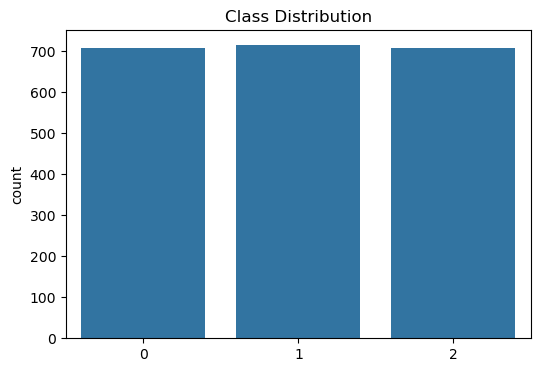

In [7]:
def perform_eda(X, y):
    df = pd.DataFrame(X)
    df['label'] = y
    print("Feature Statistics:\n", df.describe())
    
    plt.figure(figsize=(6, 4))
    sns.countplot(x=y)
    plt.title("Class Distribution")
    plt.show()

perform_eda(X, y)

In [ ]:
def build_model(input_shape, num_classes):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_shape,)),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def classify_eeg_data(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = build_model(X_train.shape[1], len(np.unique(y)))
    
    model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))
    
    y_pred = np.argmax(model.predict(X_test), axis=1)
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

classify_eeg_data(X, y)